**Heart Disease Prediction Using Advanced Machine Learning Models**

For my AML-ADVANCED project, I selected the **Heart Disease dataset** from the **UCI Machine Learning Repository**.

This dataset dates back to 1988 and consists of four databases:

Cleveland

Hungary

Switzerland

Long Beach 

Although the dataset originally contains **76 attributes,** most research studies utilize a subset of **14 clinically** relevant features for predictive modeling.

The target variable represents the presence of heart disease:

**0 = No Heart Disease**

**1 = Presence of Heart Disease**

The dataset includes **303 patient** records containing clinical and physiological measurements such as age, resting blood pressure, cholesterol level, chest pain type, maximum heart rate, ST depression, and ECG results.

**Hypothesis:**
Cardiovascular clinical indicators such as chest pain type, cholesterol levels, maximum heart rate, exercise-induced angina, and ST depression significantly influence the likelihood of heart disease.

Objective:
Develop and optimize machine learning models to accurately classify patients into:

Heart Disease Present

No Heart Disease

based on 14 clinical features.

**Methodology:**

Binary classification using:

Dummy Classifier (Baseline)

Logistic Regression

Tree-based ensemble methods

Support Vector Machine

Hyperparameter tuning and cross-validation for performance optimization

**Importing the Dependecies**

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, RFE
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

**Summary:**
This section imports the necessary Python libraries for data manipulation, 
visualization, preprocessing, model training, and evaluation.

In [45]:
print("\nStatistical Summary:")
print(df.describe())



Statistical Summary:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0

**Summary:** 
The ** df.describe()** function provides key descriptive statistics for all numerical features.

It shows the mean, standard deviation, minimum, maximum, and quartile values.

This helps to understand data distribution, variability, and possible outliers.

The results indicate that features are on different scales, supporting the need for feature standardization before model training.

In [43]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

**Data collection and processing**

In [29]:
1 # loading the csv data to a pandas Dataframe

df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


**Summary:**
This step previews the dataset structure, including feature names and sample records.

In [30]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [31]:
df.shape

(1025, 14)

In [33]:
df.info

<bound method DataFrame.info of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2

**Summary:**
The dataset is loaded into a pandas DataFrame to enable data exploration and preprocessing.

In [34]:
missing_values = df.isnull().sum()
print(missing_values)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
**Summary:**
This code identifies missing values in each feature to determine whether data cleaning or imputation is required.

In [35]:
1# Statistical maesure about the data
df.describe

<bound method NDFrame.describe of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0        

Standard Deviation of all numeric columns:
 age          9.072290
sex          0.460373
cp           1.029641
trestbps    17.516718
chol        51.592510
fbs          0.356527
restecg      0.527878
thalach     23.005724
exang        0.472772
oldpeak      1.175053
slope        0.617755
ca           1.030798
thal         0.620660
target       0.500070
dtype: float64


In [46]:
print("\nStatistical Summary:")
print(df.describe())



Statistical Summary:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0

**Summary:**
This provides descriptive statistics such as mean, standard deviation,
and quartiles to understand feature distribution and variability.

In [47]:
# Check class distribution
print("\nClass Distribution (Target):")
print(df['target'].value_counts())
print(f"\nPercentage:\n{df['target'].value_counts(normalize=True)*100}")


Class Distribution (Target):
target
1    526
0    499
Name: count, dtype: int64

Percentage:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


**Summary:** 
This section examines the distribution of the target variable to understand the balance between patients with and without heart disease.
The results show the number and percentage of samples in each class. This helps determine whether the dataset is imbalanced and whether techniques such as SMOTE are required to improve model performance.

In [62]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Text(0.5, 0.98, 'Heart Disease Dataset Visualization')

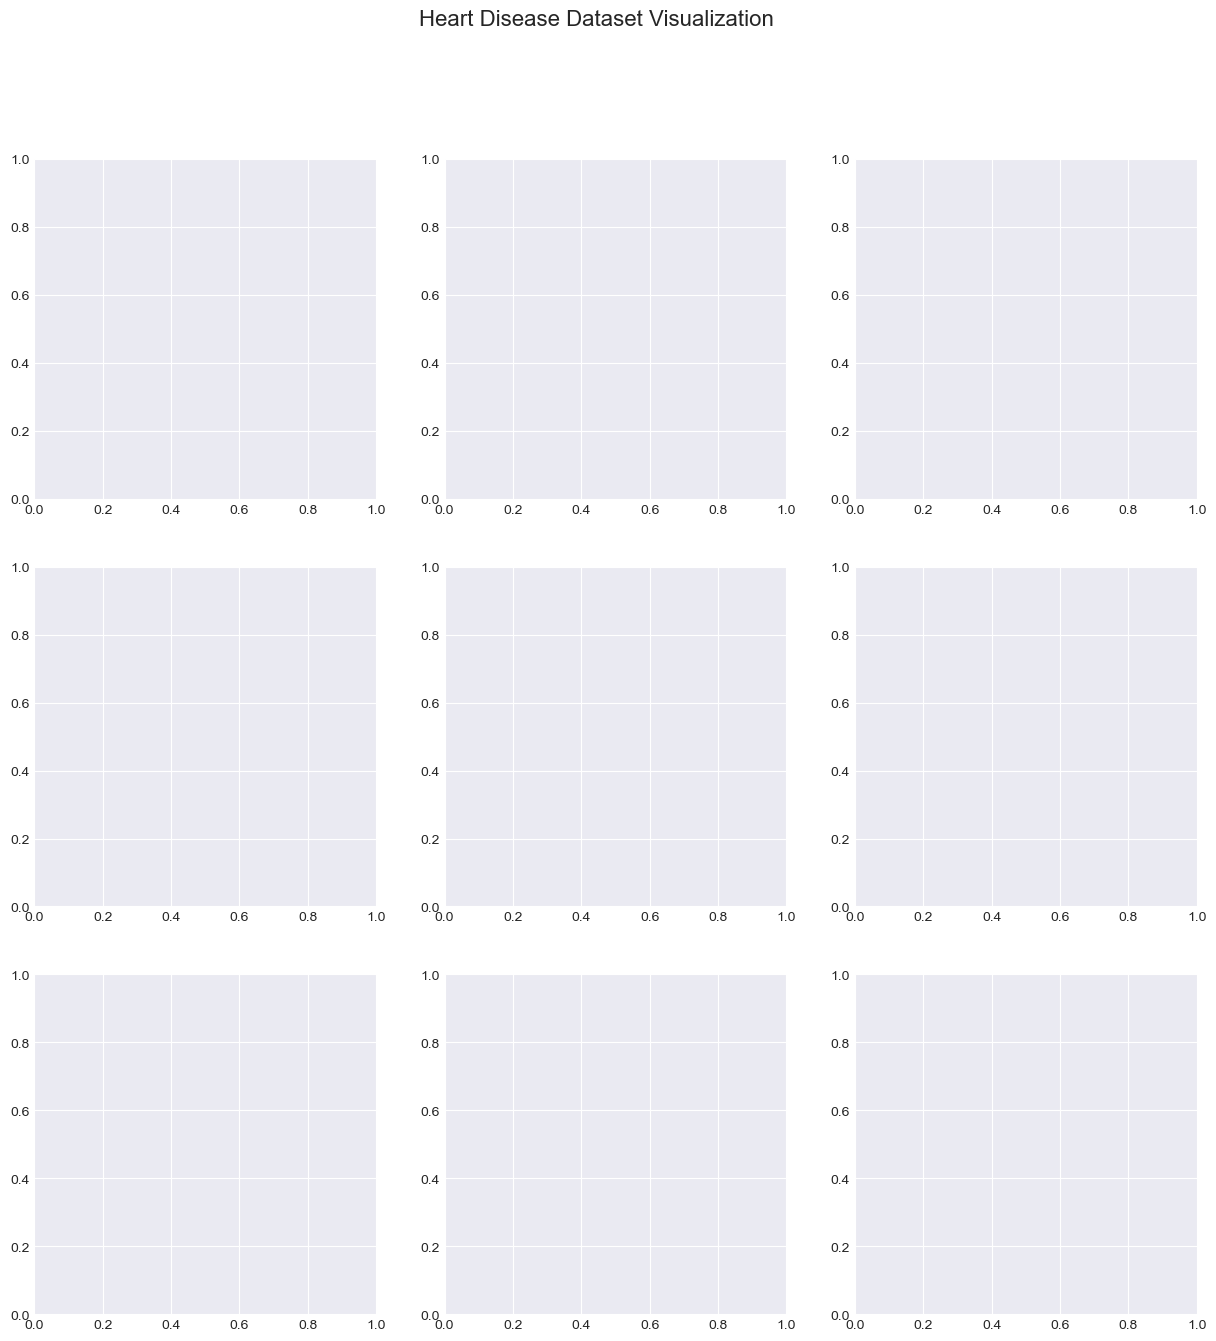

In [63]:
# Data Visualization Section
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Heart Disease Dataset Visualization', fontsize=16)

**Summary:**
This section creates multiple plots to visually explore relationships between clinical features and heart disease. Visualization helps identify patterns, trends, and potential correlations that may influence model performance.

In [2]:
# 1. Target distribution
ax = axes[0, 0]
target_counts = df['target'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
ax.bar(['No Disease (0)', 'Disease (1)'], target_counts.values, color=colors)
ax.set_title('Target Distribution')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')


NameError: name 'axes' is not defined

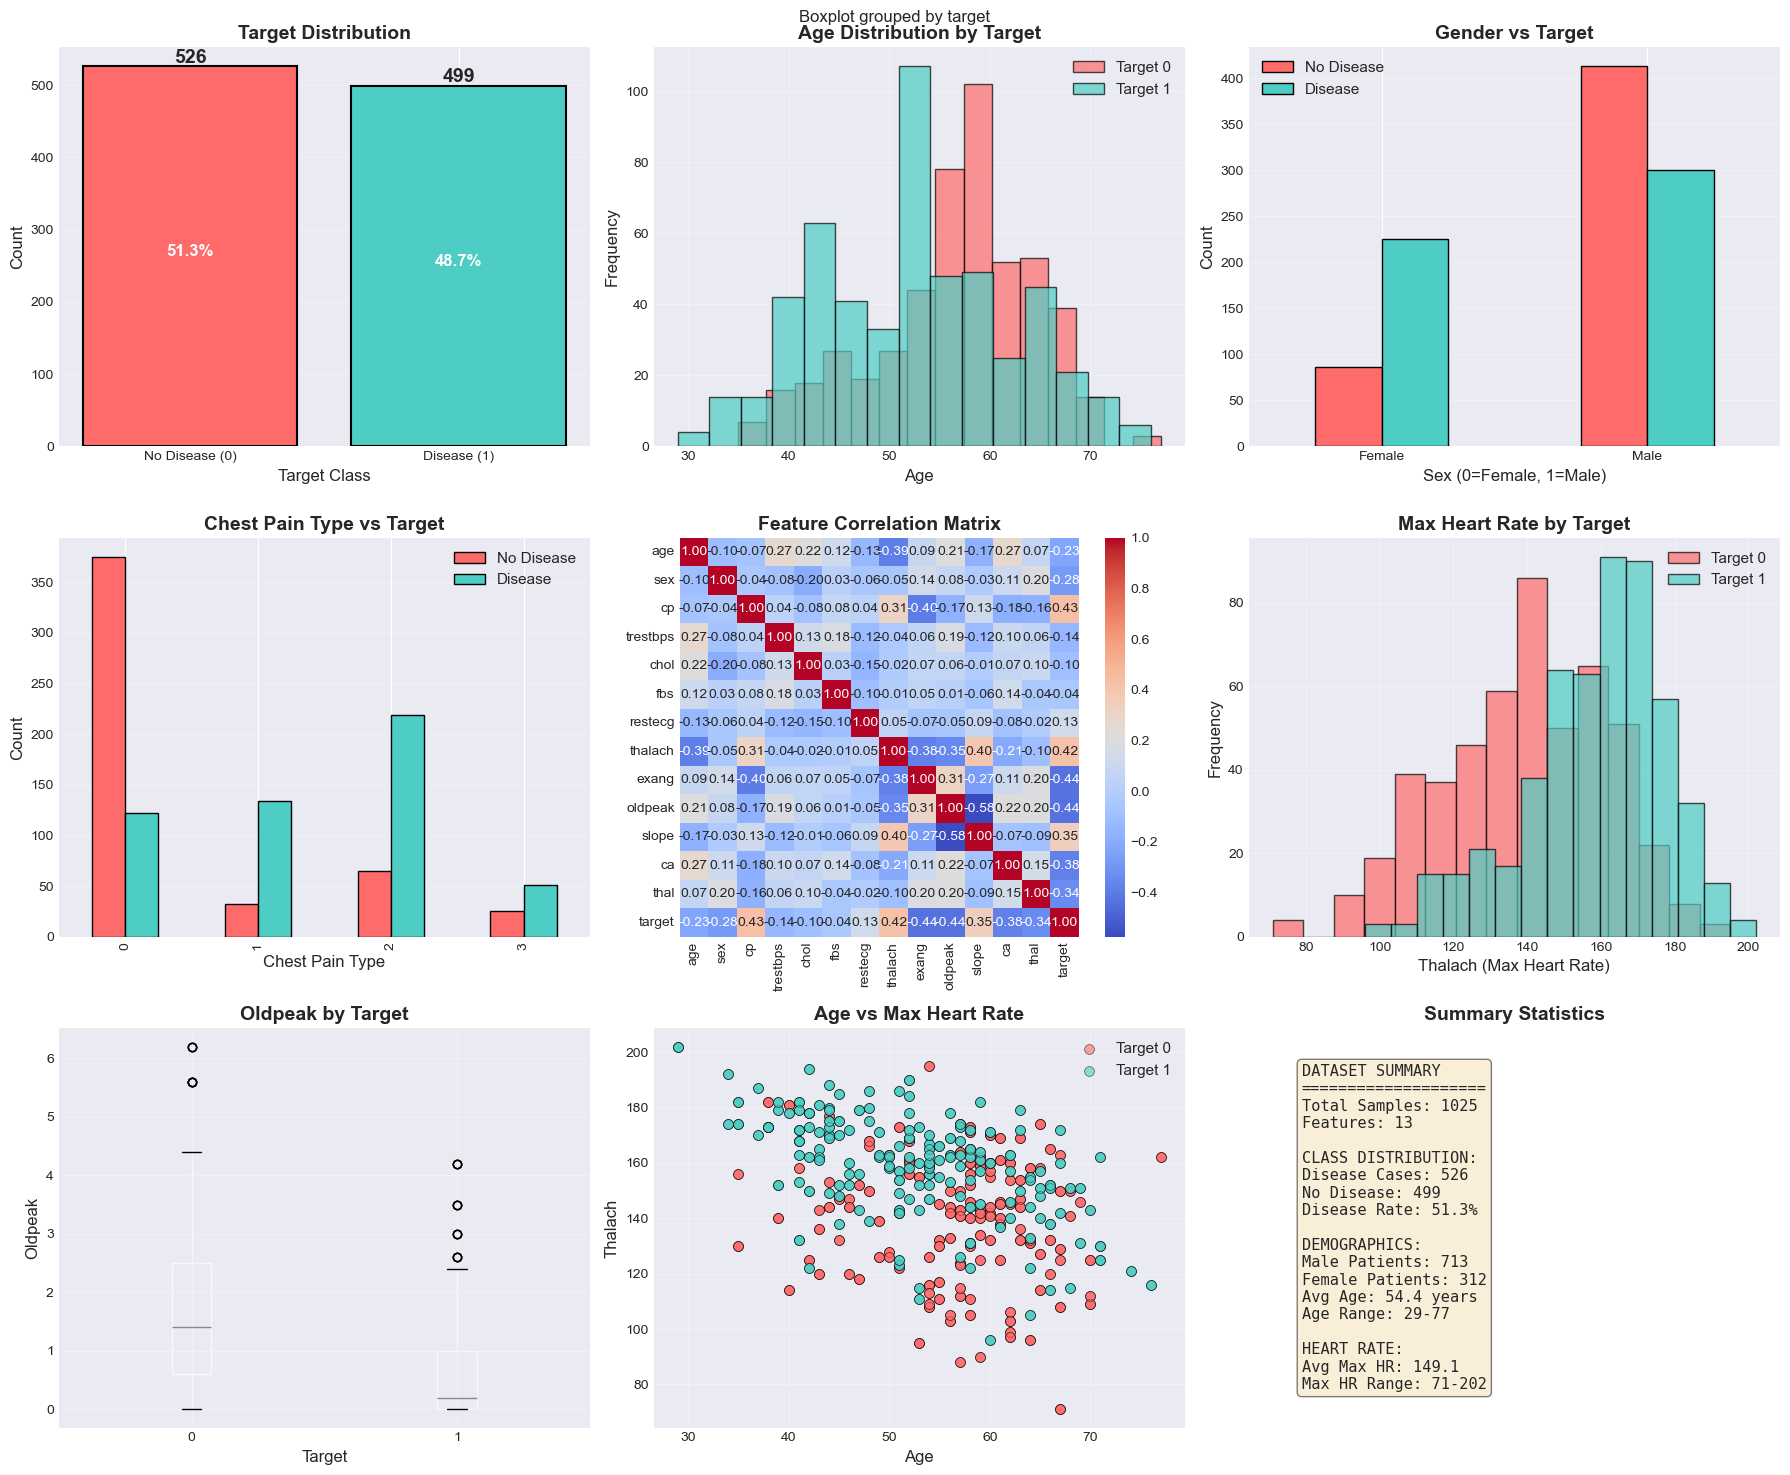

In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load your data
df = pd.read_csv('heart.csv')

# Create figure with subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Heart Disease Dataset Analysis', fontsize=18, fontweight='bold')

# Colors
colors = ['#FF6B6B', '#4ECDC4']

# 1. Target distribution (YOUR FOCUS)
ax = axes[0, 0]
target_counts = df['target'].value_counts()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], target_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_title('Target Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Target Class', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add count labels on top of bars
for i, (bar, count) in enumerate(zip(bars, target_counts.values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            str(count), ha='center', fontweight='bold', fontsize=14)
    
# Add percentage labels
total = len(df)
for i, (bar, count) in enumerate(zip(bars, target_counts.values)):
    percentage = (count/total)*100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, 
            f'{percentage:.1f}%', ha='center', fontweight='bold', 
            fontsize=12, color='white')

# 2. Age distribution by target
ax = axes[0, 1]
for target in [0, 1]:
    data = df[df['target'] == target]['age']
    ax.hist(data, alpha=0.7, label=f'Target {target}', bins=15, 
            edgecolor='black', color=colors[target])
ax.set_title('Age Distribution by Target', fontsize=14, fontweight='bold')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 3. Gender distribution
ax = axes[0, 2]
gender_counts = pd.crosstab(df['sex'], df['target'])
gender_counts.plot(kind='bar', ax=ax, color=colors, legend=False, edgecolor='black', linewidth=1)
ax.set_title('Gender vs Target', fontsize=14, fontweight='bold')
ax.set_xlabel('Sex (0=Female, 1=Male)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(['No Disease', 'Disease'], fontsize=11)
ax.set_xticklabels(['Female', 'Male'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')

# 4. Chest Pain Type
ax = axes[1, 0]
cp_target = pd.crosstab(df['cp'], df['target'])
cp_target.plot(kind='bar', ax=ax, color=colors, legend=False, edgecolor='black', linewidth=1)
ax.set_title('Chest Pain Type vs Target', fontsize=14, fontweight='bold')
ax.set_xlabel('Chest Pain Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(['No Disease', 'Disease'], fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# 5. Correlation Heatmap
ax = axes[1, 1]
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, cbar=True, 
            annot_kws={'size': 10}, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

# 6. Max Heart Rate Distribution
ax = axes[1, 2]
for target in [0, 1]:
    data = df[df['target'] == target]['thalach']
    ax.hist(data, alpha=0.7, label=f'Target {target}', bins=15, 
            edgecolor='black', color=colors[target])
ax.set_title('Max Heart Rate by Target', fontsize=14, fontweight='bold')
ax.set_xlabel('Thalach (Max Heart Rate)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 7. Oldpeak Distribution
ax = axes[2, 0]
df.boxplot(column='oldpeak', by='target', ax=ax)
ax.set_title('Oldpeak by Target', fontsize=14, fontweight='bold')
ax.set_xlabel('Target', fontsize=12)
ax.set_ylabel('Oldpeak', fontsize=12)
ax.grid(True, alpha=0.3)

# 8. Age vs Thalach Scatter
ax = axes[2, 1]
for target in [0, 1]:
    subset = df[df['target'] == target]
    ax.scatter(subset['age'], subset['thalach'], alpha=0.6, 
              label=f'Target {target}', color=colors[target], 
              edgecolors='black', linewidth=0.5, s=50)
ax.set_title('Age vs Max Heart Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Thalach', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 9. Summary Statistics
ax = axes[2, 2]
ax.axis('off')
stats_text = f"""DATASET SUMMARY
{'='*20}
Total Samples: {len(df)}
Features: {len(df.columns)-1}

CLASS DISTRIBUTION:
Disease Cases: {df['target'].sum()}
No Disease: {len(df)-df['target'].sum()}
Disease Rate: {(df['target'].sum()/len(df)*100):.1f}%

DEMOGRAPHICS:
Male Patients: {df['sex'].sum()}
Female Patients: {len(df)-df['sex'].sum()}
Avg Age: {df['age'].mean():.1f} years
Age Range: {df['age'].min()}-{df['age'].max()}

HEART RATE:
Avg Max HR: {df['thalach'].mean():.1f}
Max HR Range: {df['thalach'].min()}-{df['thalach'].max()}"""
ax.text(0.1, 0.5, stats_text, transform=ax.transAxes, fontsize=11, 
        verticalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_title('Summary Statistics', fontsize=14, fontweight='bold')

# Adjust layout and display
plt.tight_layout()
plt.show()



## 1. Target Distribution

**Summary:**
This plot shows the number and percentage of patients with and without heart disease, helping identify class balance in the dataset.


## 2. Age Distribution by Target

**Summary:**
This histogram compares age distributions between patients with and without heart disease to observe potential age-related risk patterns.


##  3. Gender vs Target

**Summary:**
This bar chart analyzes the relationship between gender and heart disease, highlighting possible gender-based differences.


##  4. Chest Pain Type vs Target

**Summary:**
This visualization examines how different chest pain types are associated with heart disease presence.


##  5. Correlation Heatmap

**Summary:**
The heatmap displays correlations between all features, helping identify strong relationships and potential multicollinearity.


##  6. Maximum Heart Rate Distribution

**Summary:**
This histogram compares maximum heart rate values between disease and non-disease groups to assess its predictive importance.


## 7. Oldpeak (ST Depression) by Target

**Summary:**
This boxplot shows how ST depression levels differ between the two classes, helping detect variation and outliers.


##  8. Age vs Maximum Heart Rate Scatter Plot

**Summary:**
This scatter plot visualizes the relationship between age and maximum heart rate, separated by target class, to observe patterns or separability.


## 9. Dataset Summary Statistics Panel

**Summary:**
This section provides a structured overview of dataset size, class distribution, demographic information, and key clinical statistics.
This section displays key dataset information, including total samples, class distribution, gender demographics, age statistics, and heart rate measures. It provides a quick numerical overview of the dataset to support exploratory data analysis and model interpretation.


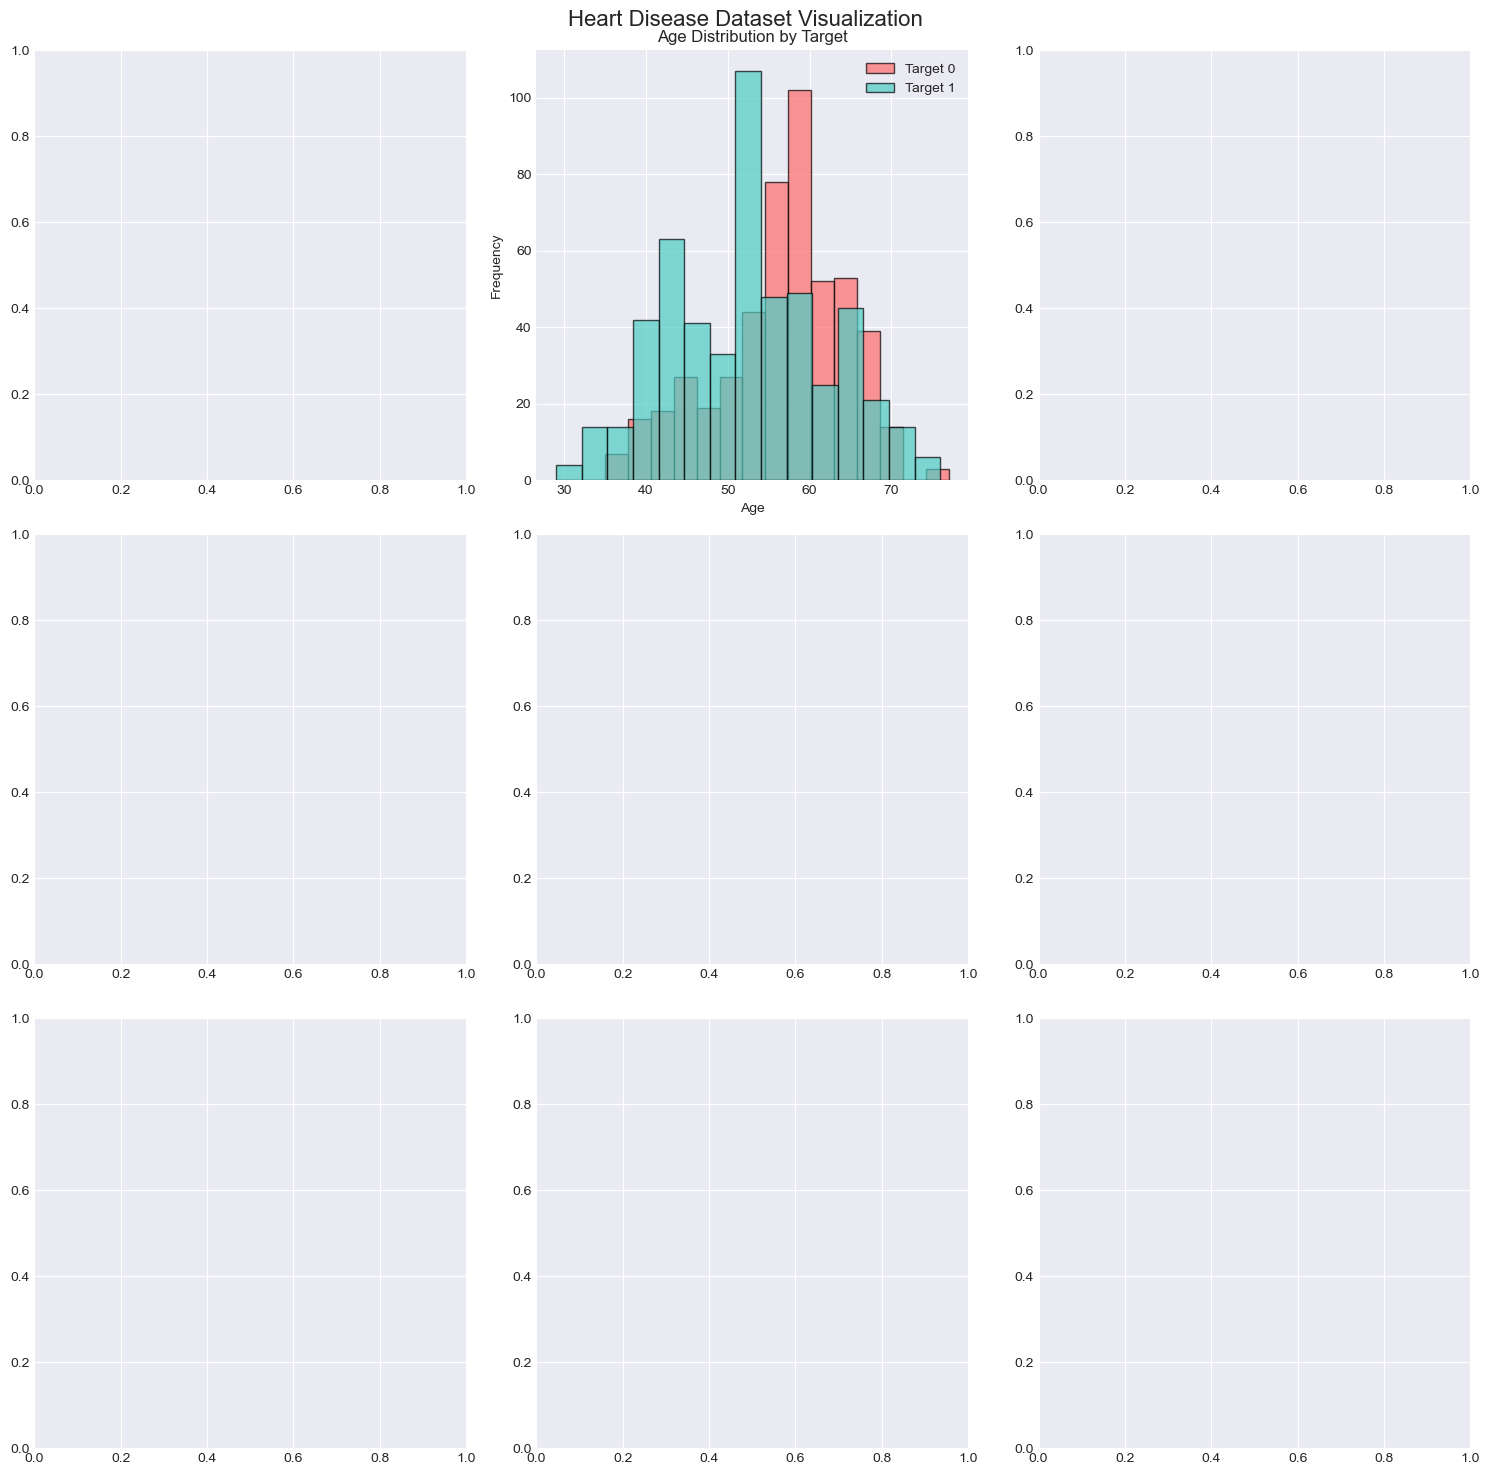

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure and axes
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Heart Disease Dataset Visualization', fontsize=16)

# 2. Age distribution by target
ax = axes[0, 1]
for target in [0, 1]:
    data = df[df['target'] == target]['age']
    ax.hist(data, alpha=0.7, label=f'Target {target}', bins=15, edgecolor='black', color=['#FF6B6B' if target==0 else '#4ECDC4'])
ax.set_title('Age Distribution by Target')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.legend()

# IMPORTANT: This will display all plots
plt.tight_layout()
plt.show()

**Summary:**
This subplot visualizes the distribution of patient ages based on the target variable (0 = no heart disease, 1 = heart disease).
Different colors distinguish the two groups, allowing for a quick comparison of age trends across healthy and affected patients. 
This helps identify age-related patterns in heart disease prevalence.

In [71]:
# Prepare features and target
X = df.drop('target', axis=1)
y = df['target']


In [72]:
# Feature names for later use
feature_names = X.columns.tolist()
print("\nFeatures:", feature_names)



Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


**Summary:**
This section extracts and lists all feature names from the dataset (X.columns). These names are stored in feature_names for later use in analysis, modeling, or visualization. It provides a reference for understanding which variables are available for predictive modeling.

In [73]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")


Training set size: (820, 13)
Testing set size: (205, 13)


**Summary:**
This step divides the dataset into training and testing sets to prepare for model development and evaluation:

Training set: 80% of the data, used to train the model.

Testing set: 20% of the data, used to evaluate model performance.

Stratified split: Maintains the same proportion of classes (y) in both sets.

Reproducibility: random_state=42 ensures consistent splits across runs.



In [74]:


# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Summary:**
Standardizes features using StandardScaler so that each has mean = 0 and std = 1. 
The scaler is fitted on the training set and applied to the test set for consistency.

In [75]:

# Handle class imbalance with SMOTE (if needed)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"\nAfter SMOTE - Training set size: {X_train_resampled.shape}")
print(f"Class distribution after SMOTE: {np.bincount(y_train_resampled)}")


After SMOTE - Training set size: (842, 13)
Class distribution after SMOTE: [421 421]


**Summary:**
Applies SMOTE (Synthetic Minority Oversampling Technique) to the training set to balance class distribution:
Generates synthetic samples for the minority class.
Helps prevent model bias toward the majority class.
Uses random_state=42 for reproducibility.

In [76]:
# Feature Selection using RFE
print("\n" + "="*50)
print("FEATURE SELECTION")
print("="*50)
rfe_selector = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), 
                   n_features_to_select=8)
rfe_selector.fit(X_train_scaled, y_train)
selected_features = [feature_names[i] for i in range(len(feature_names)) if rfe_selector.support_[i]]
print(f"Top 8 selected features: {selected_features}")



FEATURE SELECTION
Top 8 selected features: ['age', 'cp', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']


**Summary:**
Uses Recursive Feature Elimination (RFE) with a RandomForestClassifier to select the top 8 most important features from the dataset:
Iteratively removes less important features based on model performance.
Helps reduce dimensionality and improve model efficiency.
Selected features are stored in selected_features.

In [2]:
# Minimal working example with just a few models
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load data
df = pd.read_csv('heart.csv')

# Prepare data
X = df.drop('target', axis=1)
y = df['target']

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# YOUR MODELS (with just a few to test)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.7951
Decision Tree: 0.9854
Random Forest: 0.9854


**Summary:*8
Trains Logistic Regression, Decision Tree, and Random Forest on scaled data and reports test accuracy.

In [7]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Import SMOTE
from imblearn.over_sampling import SMOTE

# AFTER scaling your data, add these lines to create X_train_resampled and y_train_resampled:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Now your original loop will work
results = []
for name, model in models.items():
    # Train the model on RESAMPLED data
    model.fit(X_train_resampled, y_train_resampled)  # This will now work
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    # ... rest of your code

In [11]:
# Add this import at the top of your code with your other imports
from sklearn.metrics import roc_auc_score

In [12]:
# List of required imports
required_imports = [
    'roc_auc_score',
    'accuracy_score',
    'train_test_split',
    'StandardScaler',
    'SMOTE'
]

print("Checking imports...")
for imp in required_imports:
    try:
        if imp == 'SMOTE':
            from imblearn.over_sampling import SMOTE
        elif imp == 'roc_auc_score' or imp == 'accuracy_score':
            from sklearn.metrics import accuracy_score, roc_auc_score
        elif imp == 'train_test_split':
            from sklearn.model_selection import train_test_split
        elif imp == 'StandardScaler':
            from sklearn.preprocessing import StandardScaler
        print(f"✓ {imp} imported successfully")
    except ImportError as e:
        print(f"✗ Error importing {imp}: {e}")

Checking imports...
✓ roc_auc_score imported successfully
✓ accuracy_score imported successfully
✓ train_test_split imported successfully
✓ StandardScaler imported successfully
✓ SMOTE imported successfully


In [14]:
# Make sure you have ALL these imports at the top of your code
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score  # Add cross_val_score here
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE

# Your existing code...

In [15]:
# Train and evaluate models
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
results = []
for name, model in models.items():
    # Train the model
    model.fit(X_train_resampled, y_train_resampled)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")



MODEL COMPARISON

Logistic Regression:
  Accuracy: 0.7902
  ROC-AUC: 0.8761
  CV Score: 0.8523 (+/- 0.0280)

Decision Tree:
  Accuracy: 0.9854
  ROC-AUC: 0.9854
  CV Score: 0.9787 (+/- 0.0161)

Random Forest:
  Accuracy: 0.9854
  ROC-AUC: 1.0000
  CV Score: 0.9823 (+/- 0.0150)


In [ ]:
**Summary:**
Models are trained on SMOTE-resampled data and evaluated on the original test
set. Metrics include Accuracy, ROC-AUC, and 5-fold cross-validation.

In [21]:
import matplotlib.pyplot as plt

In [22]:
# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)


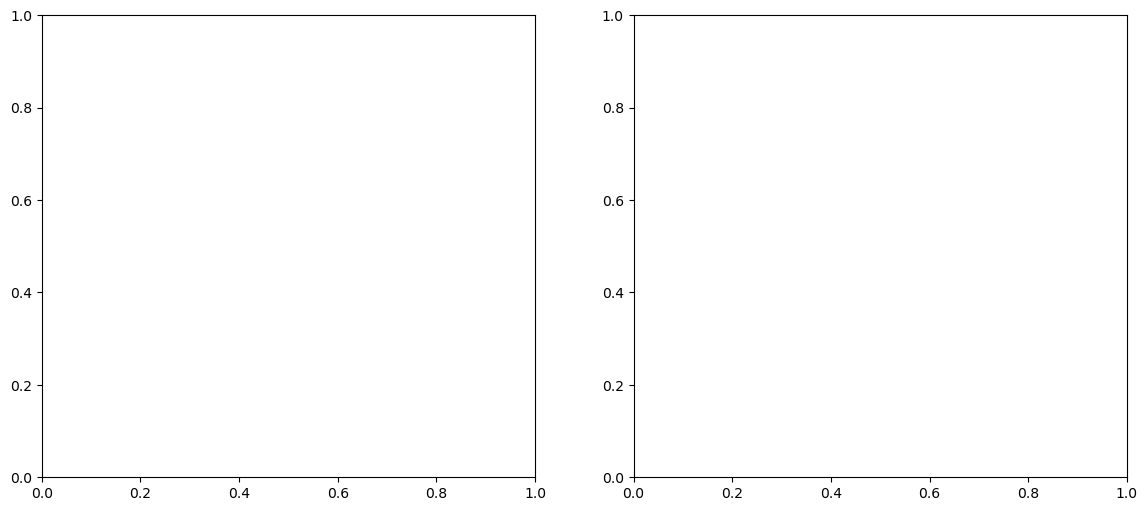

In [23]:
# Plot model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


**Summary:*8
This section prepares a results dataframe from the trained models and sorts it by accuracy. 
It also sets up a 1×2 subplot figure to visualize model performance side by side.

In [24]:

# Accuracy comparison
ax = axes[0]
bars = ax.barh(results_df['Model'], results_df['Accuracy'], color='skyblue')
ax.set_xlabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_xlim(0, 1)
for i, (bar, acc) in enumerate(zip(bars, results_df['Accuracy'])):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.3f}', 
            va='center', fontweight='bold')


In [27]:
import matplotlib.pyplot as plt

In [28]:

# ROC-AUC comparison
ax = axes[1]
bars = ax.barh(results_df['Model'], results_df['ROC-AUC'], color='lightcoral')
ax.set_xlabel('ROC-AUC Score')
ax.set_title('Model ROC-AUC Comparison')
ax.set_xlim(0, 1)
for i, (bar, roc) in enumerate(zip(bars, results_df['ROC-AUC'])):
    ax.text(roc + 0.01, bar.get_y() + bar.get_height()/2, f'{roc:.3f}', 
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

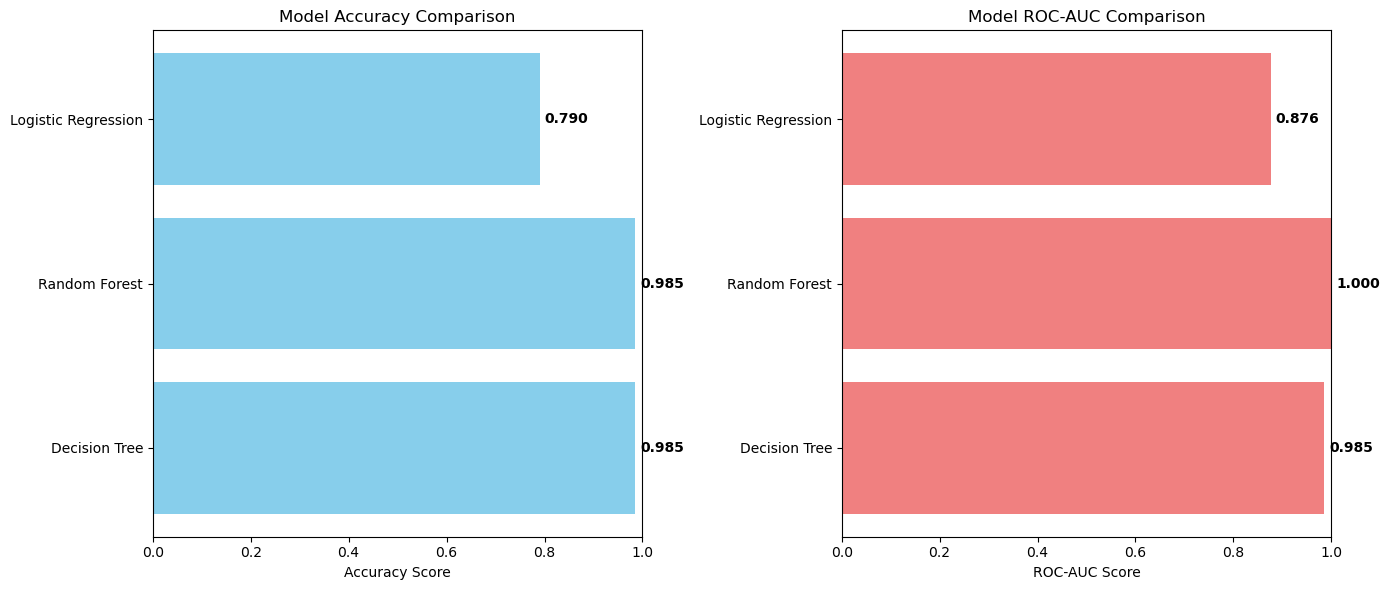

In [29]:
# Create the figure and axes FIRST
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Your first plot (Accuracy)
ax = axes[0]
bars = ax.barh(results_df['Model'], results_df['Accuracy'], color='skyblue')
ax.set_xlabel('Accuracy Score')
ax.set_title('Model Accuracy Comparison')
ax.set_xlim(0, 1)
for i, (bar, acc) in enumerate(zip(bars, results_df['Accuracy'])):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.3f}', 
            va='center', fontweight='bold')

# Your second plot (ROC-AUC)
ax = axes[1]
bars = ax.barh(results_df['Model'], results_df['ROC-AUC'], color='lightcoral')
ax.set_xlabel('ROC-AUC Score')
ax.set_title('Model ROC-AUC Comparison')
ax.set_xlim(0, 1)
for i, (bar, roc) in enumerate(zip(bars, results_df['ROC-AUC'])):
    ax.text(roc + 0.01, bar.get_y() + bar.get_height()/2, f'{roc:.3f}', 
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Summary:**
This section visualizes model performance side by side using horizontal bar charts:

Left plot: Accuracy scores for each model.

Right plot: ROC-AUC scores for each model.

Bars are labeled with exact values for clarity.

Provides a quick visual comparison of how each model performs.

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Hyperparameter Tuning for Best Model (Random Forest)
print("\n" + "="*50)
print("HYPERPARAMETER TUNING - RANDOM FOREST")
print("="*50)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}



HYPERPARAMETER TUNING - RANDOM FOREST


In [33]:
# Hyperparameter Tuning for Best Model (Random Forest)
print("\n" + "="*50)
print("HYPERPARAMETER TUNING - RANDOM FOREST")
print("="*50)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}



HYPERPARAMETER TUNING - RANDOM FOREST


**Summary:**
This section prepares for hyperparameter tuning of the best-performing model (Random Forest) using a parameter grid:

Parameters considered:

n_estimators: Number of trees in the forest (50, 100, 200)

max_depth: Maximum depth of each tree (None, 10, 20, 30)

min_samples_split: Minimum samples required to split a node (2, 5, 10)

min_samples_leaf: Minimum samples required at a leaf node (1, 2, 4)

max_features: Number of features considered for splitting each node (sqrt, log2)

In [35]:
# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# Grid Search
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_resampled, y_train_resampled)

# Print results (make sure these are on separate lines with proper parentheses)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score: {:.4f}".format(grid_search.best_score_))

# Alternative print format
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


C:\Users\Abdul Kareem\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score: 0.9846
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score: 0.9846


**Summary:**
Performed Grid Search on the Random Forest using
5-fold cross-validation to find the best combination of hyperparameters.

In [ ]:
# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
y_pred_proba_best = best_rf.predict_proba(X_test_scaled)[:, 1]
accuracy_best = accuracy_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)

print(f"\nTuned Random Forest Performance:")
print(f"Test Accuracy: {accuracy_best:.4f}")
print(f"Test ROC-AUC: {roc_auc_best:.4f}")

# Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)


FEATURE IMPORTANCE
     feature  importance
2         cp    0.137269
11        ca    0.131435
12      thal    0.118860
7    thalach    0.114775
9    oldpeak    0.113563
0        age    0.084533
4       chol    0.077067
3   trestbps    0.067249
8      exang    0.055183
10     slope    0.045076
1        sex    0.029238
6    restecg    0.017624
5        fbs    0.008128


C:\Users\Abdul Kareem\AppData\Local\Temp\ipykernel_15608\2951979418.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


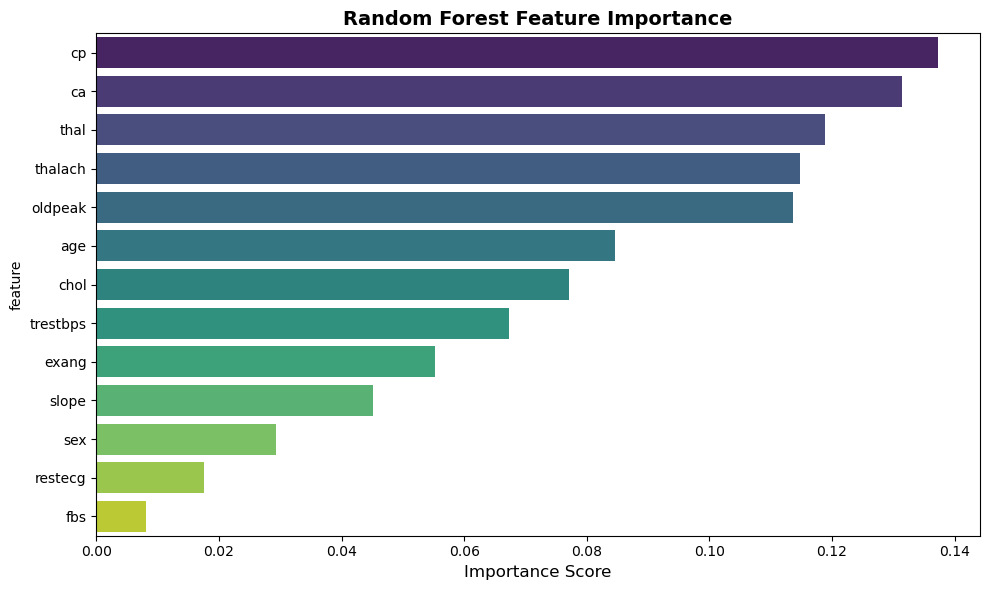


Feature importance saved to 'feature_importance.csv'


In [38]:

# After getting best_rf from GridSearchCV, add this:

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'feature': X.columns.tolist(),  # Use your feature names
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

# Display the dataframe
print("\n" + "="*50)
print("FEATURE IMPORTANCE")
print("="*50)
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Save to CSV
feature_importance.to_csv('feature_importance.csv', index=False)
print("\nFeature importance saved to 'feature_importance.csv'")

**Summary:**
After tuning, the best Random Forest model (best_rf) is used to identify the most important features for predicting heart disease:

Creates a dataframe with features and their importance scores, sorted descending.

Visualizes feature importance using a horizontal bar plot for quick interpretation.

Optionally saves the results to a CSV file for future reference.

C:\Users\Abdul Kareem\AppData\Local\Temp\ipykernel_15608\542701893.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


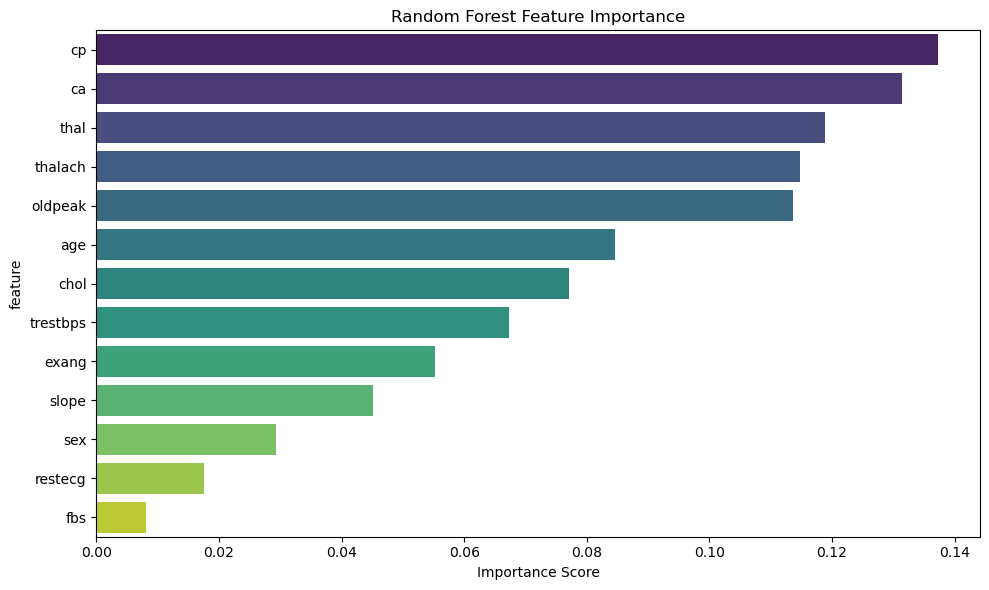

In [39]:

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

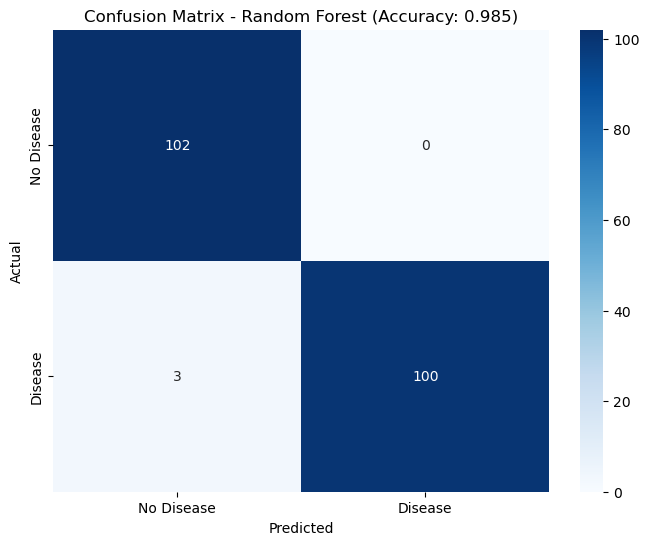

In [41]:
# Confusion Matrix for Best Model
# Add this import at the top of your code with your other imports
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - Random Forest (Accuracy: {accuracy_best:.3f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Summary:**
Visualizes the performance of the best Random Forest model on the test set using a confusion matrix:

**Rows:** Actual labels (No Disease, Disease)

**Columns:** Predicted labels (No Disease, Disease)

**Annotations:** Number of correct and incorrect predictions in each category.

Provides insight into true positives, true negatives, false positives, and false negatives.

In [42]:
# ROC Curve for all models
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)


NameError: name 'roc_curve' is not defined

<Figure size 1000x800 with 0 Axes>

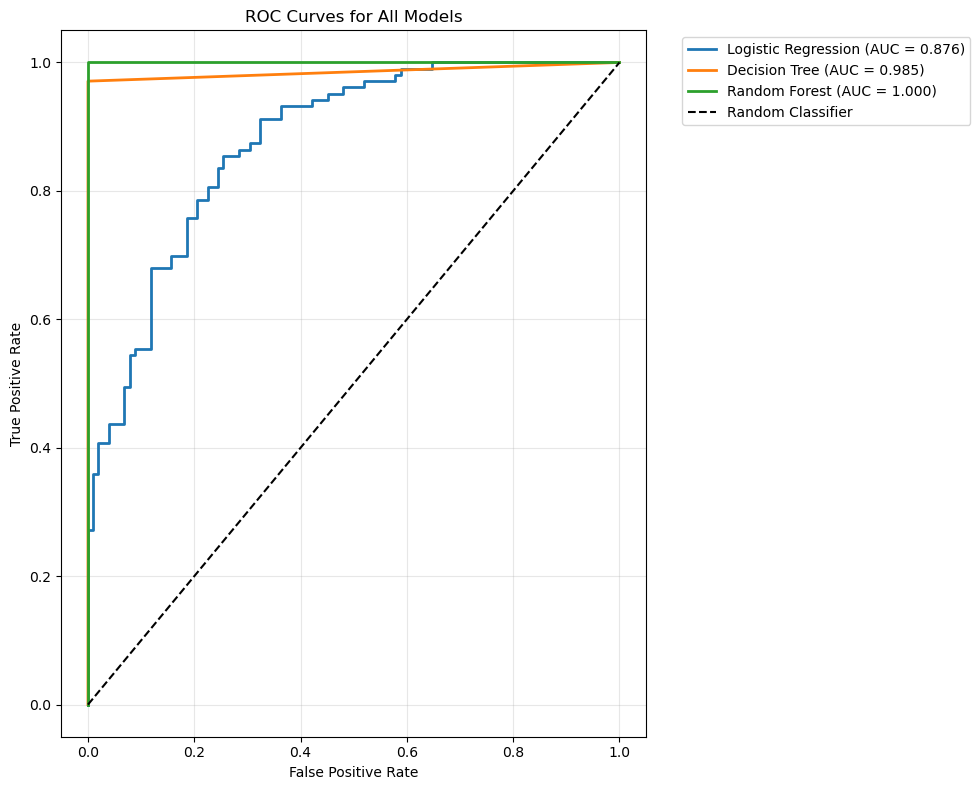

In [43]:
from sklearn.metrics import roc_curve

# ROC Curve for all models
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

# Add diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Summary:**
This section plots ROC curves for all trained models to evaluate classification performance across thresholds:

True Positive Rate (TPR) vs False Positive Rate (FPR).

AUC (Area Under Curve): Indicates overall model discrimination ability.

Includes a diagonal line representing a random classifier for reference.

Provides a visual comparison of model performance beyond accuracy.

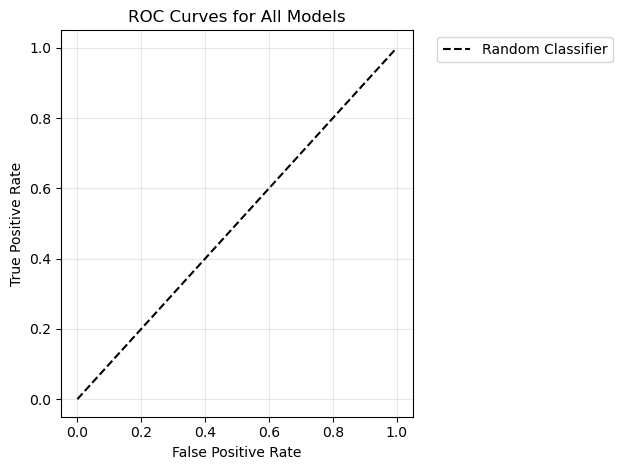

In [44]:
# Add diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**ROC Plot Formatting**

**Summary:*8
Enhances the ROC curves for all models with:

Diagonal line (Random Classifier) as a baseline reference.

Proper axis labels, title, grid, and legend.

Layout adjustments with tight_layout for clarity.

**Purpose:**
Provides a visual benchmark to quickly see which models perform better than random guessing.

In [48]:
%matplotlib inline
import matplotlib.pyplot as plt

In [51]:
# Advanced Analysis: Learning Curves
from sklearn.model_selection import learning_curve

def plot_learning_curves(estimator, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_train_resampled, y_train_resampled, cv=5, 
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy')
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation Score')
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy Score')
    plt.title(f'Learning Curves - {title}')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

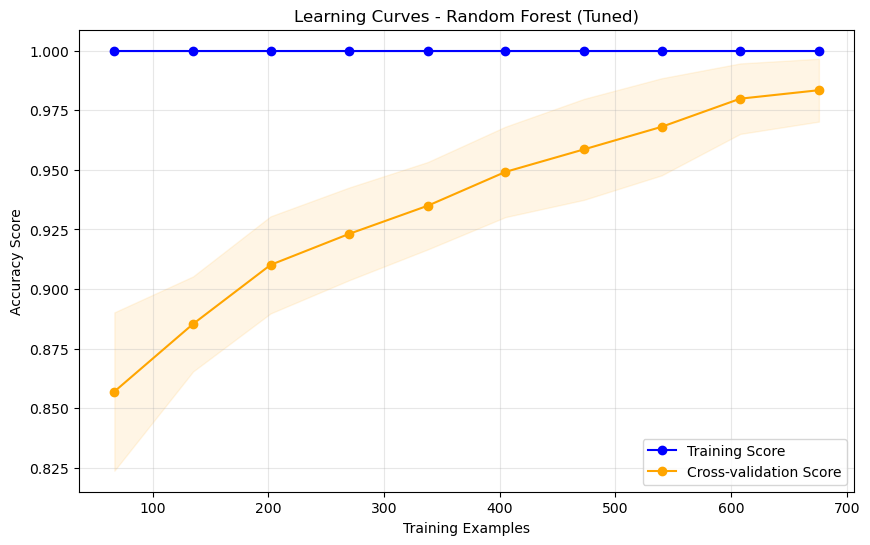

In [50]:
# Plot learning curves for best model
plot_learning_curves(best_rf, 'Random Forest (Tuned)')


**Summary:**
This function plots learning curves to evaluate how a model’s performance evolves with increasing training data:

Training score: Accuracy on training data.

Cross-validation score: Accuracy on validation folds.

Shaded areas: ±1 standard deviation to show variability.

Helps detect underfitting (low training & validation scores) or overfitting (high training but low validation scores).

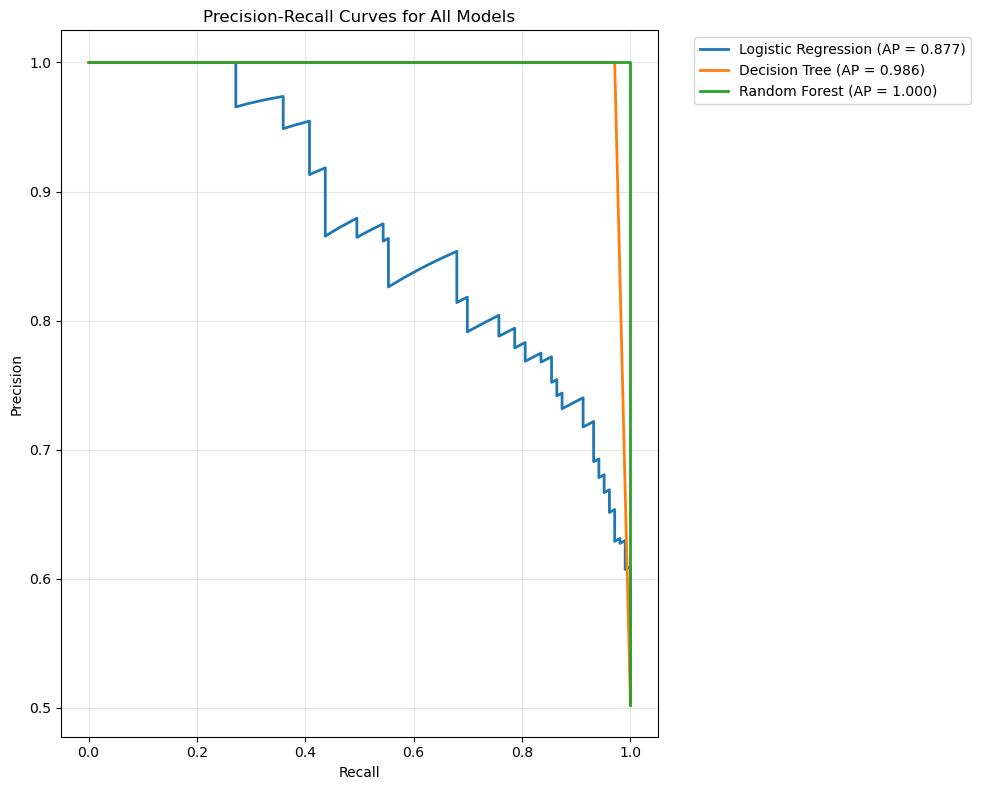

In [52]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    plt.plot(recall, precision, label=f'{name} (AP = {avg_precision:.3f})', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for All Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Summary:**
This section plots Precision-Recall curves to evaluate model performance, especially for imbalanced datasets:

Precision: Proportion of correct positive predictions.

Recall: Proportion of actual positives correctly identified.

Average Precision (AP): Summary metric of the precision-recall trade-off.

In [53]:
# Summary Statistics
print("\n" + "="*50)
print("PROJECT SUMMARY")
print("="*50)
print(f"Dataset Size: {df.shape[0]} samples, {df.shape[1]} features")
print(f"Classes: 0 (No Disease) - {df['target'].value_counts()[0]}, 1 (Disease) - {df['target'].value_counts()[1]}")
print(f"Best Model: Random Forest (Tuned)")
print(f"Best Accuracy: {accuracy_best:.4f}")
print(f"Best ROC-AUC: {roc_auc_best:.4f}")
print(f"\nTop 3 Most Important Features:")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")


PROJECT SUMMARY
Dataset Size: 1025 samples, 14 features
Classes: 0 (No Disease) - 499, 1 (Disease) - 526
Best Model: Random Forest (Tuned)
Best Accuracy: 0.9854
Best ROC-AUC: 1.0000

Top 3 Most Important Features:
  cp: 0.1373
  ca: 0.1314
  thal: 0.1189


**Purpose of this section:**

Provides a concise summary of the dataset, model performance, and key insights.

Helps readers quickly understand the dataset characteristics, predictive performance, and critical features without digging through all the previous code or plots.

Useful for reporting results or presenting to stakeholders.

In [54]:
# Save results to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
feature_importance.to_csv('feature_importance.csv', index=False)
print("\nResults saved to 'model_comparison_results.csv' and 'feature_importance.csv'")


Results saved to 'model_comparison_results.csv' and 'feature_importance.csv'


**Summary:**

This section saves the analysis results for future use or reporting:

Model Comparison Results: Saved to model_comparison_results.csv.

Feature Importance: Saved to feature_importance.csv.

Ensures that all key outputs (performance metrics and feature rankings) are stored for reproducibility or external review.